Linear regression - exercise 1
1. Into the execution environment in the notebook or on Google drive, transfer the data file (kc_house_data.csv) about real estate in King County, USA (the same one used in the presentation on the implementation of the linear regression model in Python).
2. Import all necessary methods from libraries (or modules from these libraries).
3. Load the data frame file into the Pandas library. Assign the data frame to a variable named housing_df.
4. Display the first dozen or so data records to see how the data looks.
5. Remove unnecessary columns from the dataset.
6. Using the methods you have learned, verify the presence of missing values in the dataset.
7. Generate and visualize the correlation matrix. You can verify the linearity of the correlation of the selected variables with the independent variable (price) graphically.
8. Using the selected graphs, check the presence of outliers. Use scatter plots of the selected variables and the dependent variable price to accurately identify observations that have outliers. Use the method of your choice (e.g., reading from the graph and filtering, IQR method) to remove outliers.
9. Divide the dataset into training and test datasets.
10. Define and train the model using the training data. Make predictions on the test data.
11. Using the .score method, check the score of the metric.
12. Use standardization/normalization of independent variables and check whether it positively affected the quality of the model. Perform the standardization on the variable X and then train the model, make a prediction on the test set and calculate the R2 metric and compare with the previously calculated value.
13. Save the prepared dataset to .csv file. You will use it to build more models during this day.

In [123]:
try:
    import google.colab
    print("Using Google Colab runtime")
except ImportError:
    print("Using a local runtime")

Using a local runtime


In [124]:
import pandas as pd
housing_df = pd.read_csv(r"C:\Users\UrosVukmanovic\Data_Science_Coders_Lab\ML\MAL_downloadable materials_session 1\Day 1\data\kc_house_data.csv")
housing_df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


1. Check and clean data

In [125]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [126]:
housing_df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [127]:
housing_df = housing_df.drop(columns=["date", "id"])



In [128]:
housing_df.head()


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


Generate and visualize the correlation matrix. You can verify the linearity of the correlation of the selected variables with the independent variable (price) graphically.

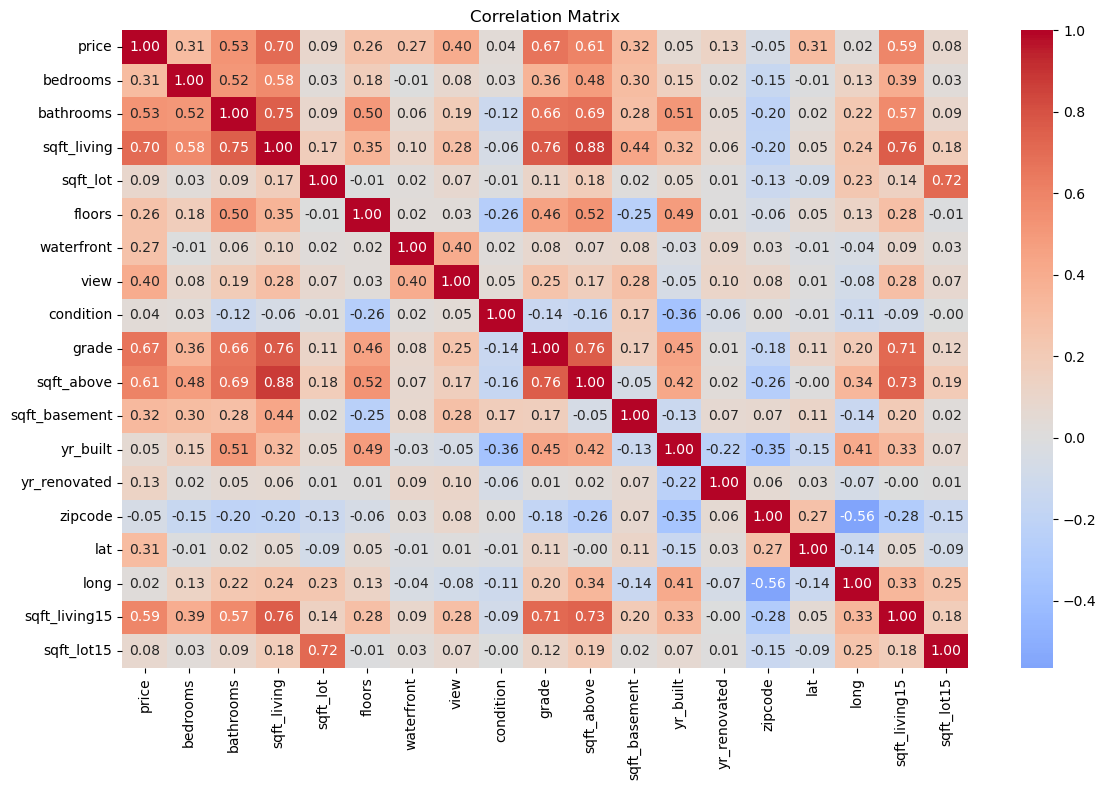

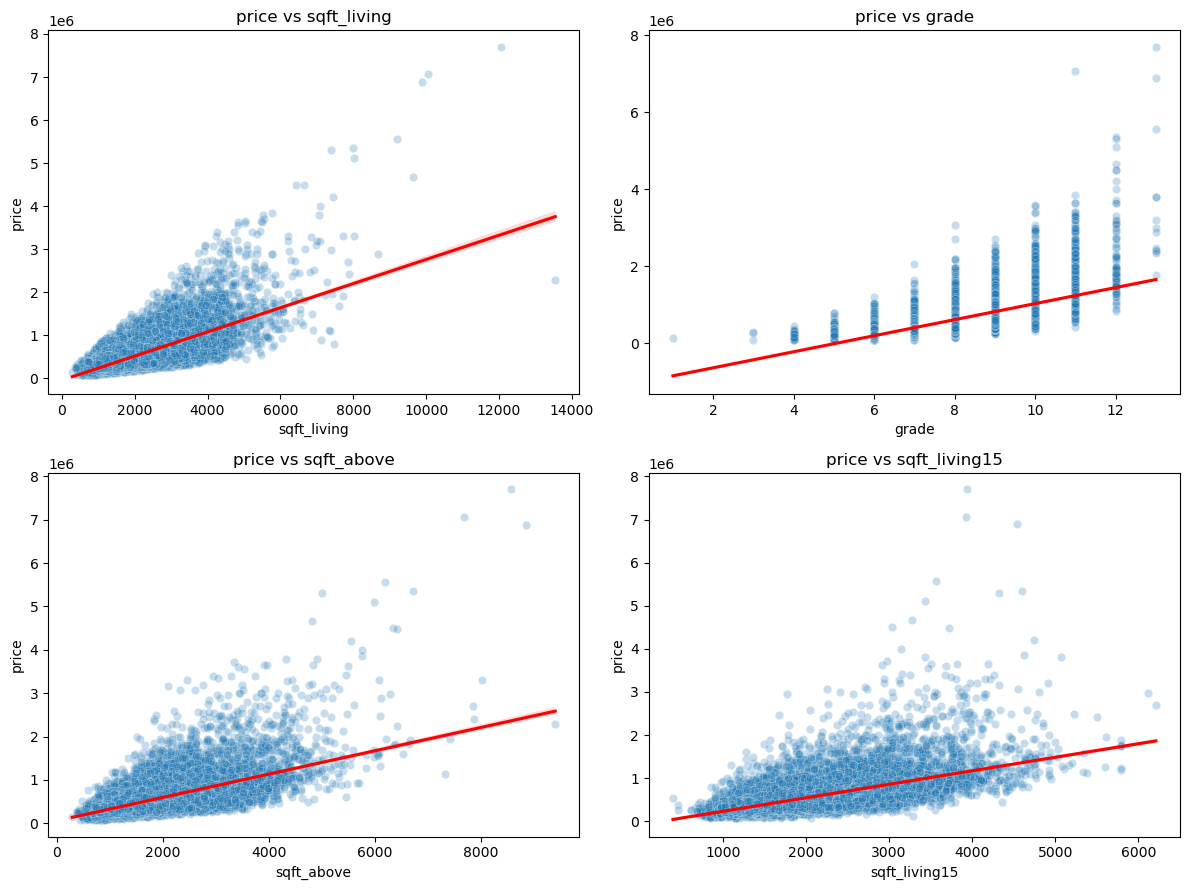

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64

In [129]:
# Import Matplotlib for creating charts and Seaborn for statistical visualizations.
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only numeric columns because correlation is calculated between numerical values.
numeric_df = housing_df.select_dtypes(include="number")

# Calculate the pairwise correlation between all numeric columns.
correlation_matrix = numeric_df.corr()

# Create a figure for the correlation heatmap.
plt.figure(figsize=(12, 8))

# Display correlation values using color intensity and numeric annotations.
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Measure each variable's absolute correlation with price and sort from strongest to weakest.
price_correlations = correlation_matrix["price"].drop("price").abs().sort_values(ascending=False)

# Select the four variables most strongly correlated with price.
selected_variables = price_correlations.head(4).index

# Create a 2-by-2 layout for the four price relationship plots.
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Plot each selected variable against price and add a red linear trend line.
for axis, variable in zip(axes.ravel(), selected_variables):
    sns.scatterplot(data=housing_df, x=variable, y="price", alpha=0.25, ax=axis)
    sns.regplot(data=housing_df, x=variable, y="price", scatter=False, color="red", ax=axis)
    axis.set_title(f"price vs {variable}")

# Adjust spacing so the subplot titles and axes do not overlap.
plt.tight_layout()
plt.show()

# Display all variables ranked by their signed correlation with price.
correlation_matrix["price"].sort_values(ascending=False)

In [130]:
# Determing outlierss and IQR

Q1 = housing_df[["sqft_living","grade","sqft_above","sqft_living15"]].quantile(0.25)
Q3 = housing_df[["sqft_living","grade","sqft_above","sqft_living15"]].quantile(0.75)
 
IQR = Q3 - Q1
IQR

sqft_living      1123.0
grade               1.0
sqft_above       1020.0
sqft_living15     870.0
dtype: float64

In [131]:
# Filtering outliers from the DataFrame (outliers can strongly affect linear regression models).
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep rows whose values for every selected variable fall within its IQR bounds.
selected_columns = ["sqft_living", "grade", "sqft_above", "sqft_living15"]
outlier_mask = (
    housing_df[selected_columns].ge(lower_bound)
    & housing_df[selected_columns].le(upper_bound)
).all(axis=1)
housing_df = housing_df.loc[outlier_mask].copy()

print("Rows after filtering:", housing_df.shape[0])
housing_df.head(5)

Rows after filtering: 19441


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [132]:
print("Rows after filtering:", housing_df.shape[0])

Rows after filtering: 19441


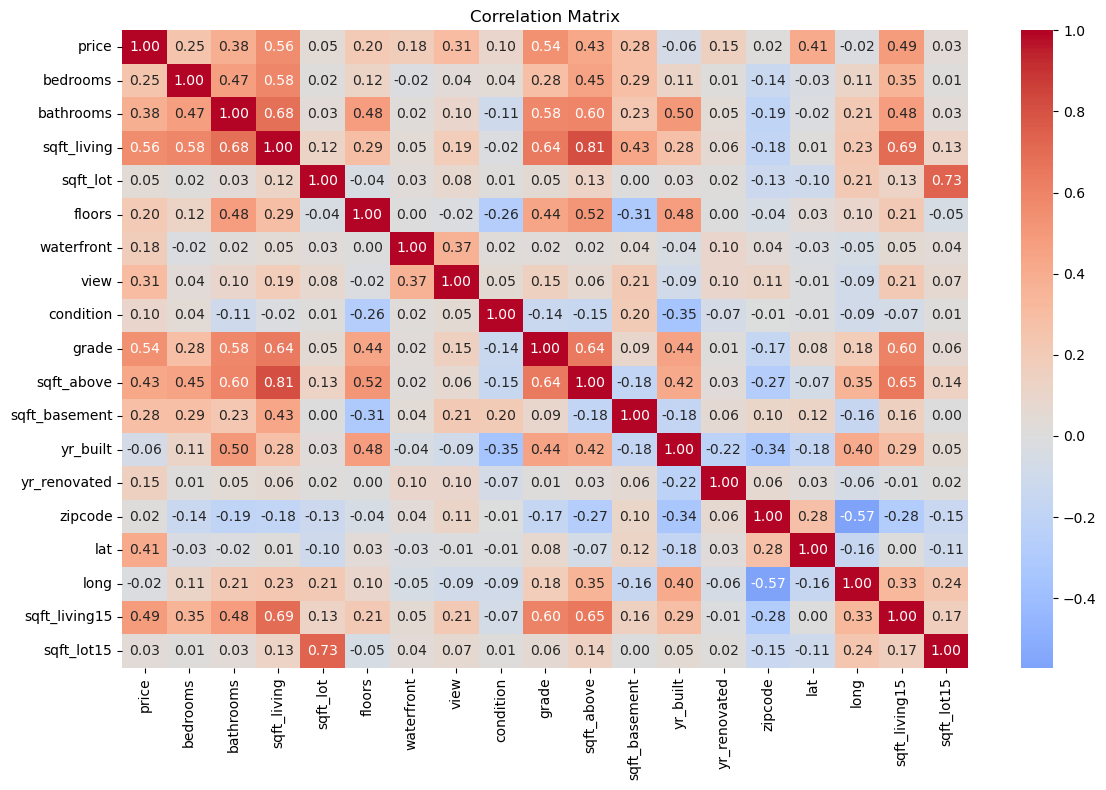

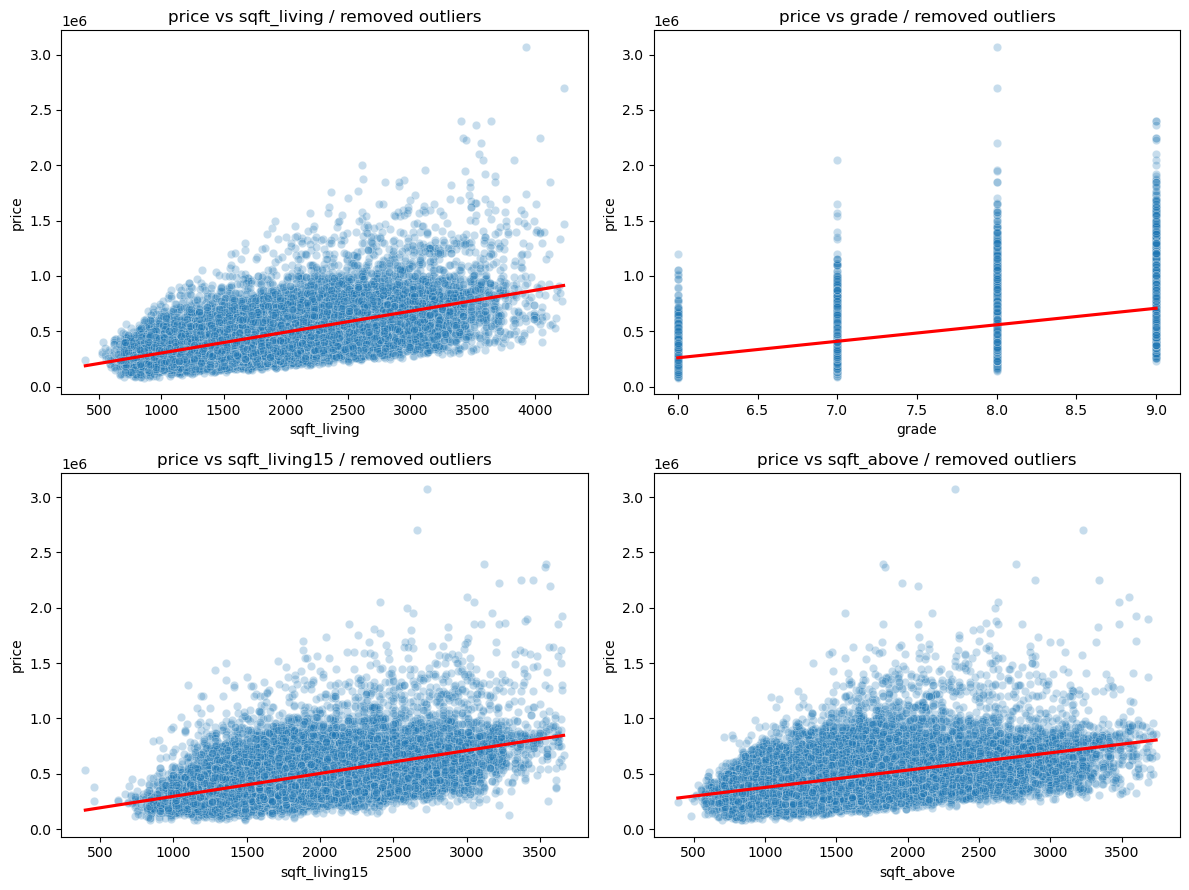

price            1.000000
sqft_living      0.559675
grade            0.544246
sqft_living15    0.488952
sqft_above       0.425467
lat              0.409580
bathrooms        0.380913
view             0.307402
sqft_basement    0.283212
bedrooms         0.253936
floors           0.203770
waterfront       0.176991
yr_renovated     0.147019
condition        0.098884
sqft_lot         0.046331
sqft_lot15       0.033784
zipcode          0.016832
long            -0.022726
yr_built        -0.063373
Name: price, dtype: float64

In [133]:
# Keep only numeric columns because correlation is calculated between numerical values.
numeric_df = housing_df.select_dtypes(include="number")

# Calculate the pairwise correlation between all numeric columns.
correlation_matrix = numeric_df.corr()

# Create a figure for the correlation heatmap.
plt.figure(figsize=(12, 8))

# Display correlation values using color intensity and numeric annotations.
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Measure each variable's absolute correlation with price and sort from strongest to weakest.
price_correlations = correlation_matrix["price"].drop("price").abs().sort_values(ascending=False)

# Select the four variables most strongly correlated with price.
selected_variables = price_correlations.head(4).index

# Create a 2-by-2 layout for the four price relationship plots.
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Plot each selected variable against price and add a red linear trend line.
for axis, variable in zip(axes.ravel(), selected_variables):
    sns.scatterplot(data=housing_df, x=variable, y="price", alpha=0.25, ax=axis)
    sns.regplot(data=housing_df, x=variable, y="price", scatter=False, color="red", ax=axis)
    axis.set_title(f"price vs {variable} / removed outliers")

# Adjust spacing so the subplot titles and axes do not overlap.
plt.tight_layout()
plt.show()

# Display all variables ranked by their signed correlation with price.
correlation_matrix["price"].sort_values(ascending=False)

In [134]:
# Train test split data set

from sklearn.model_selection import train_test_split

X = housing_df.drop("price", axis=1)
y = housing_df["price"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)


In [135]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [136]:
print(f"Coeficient values: {lin_reg.coef_}")
print(f"Intercept coeficient value: {lin_reg.intercept_}")

Coeficient values: [-1.20342978e+04  2.10639513e+04  5.94539066e+01  2.23063631e-01
  3.72586657e+04  2.98198640e+05  4.08111338e+04  2.78178115e+04
  8.79583373e+04  2.71656449e+01  3.22882619e+01 -2.19715270e+03
  2.00886245e+01 -3.08491635e+02  5.61917036e+05 -7.41828408e+04
  5.35944261e+01 -2.05536496e-01]
Intercept coeficient value: -1815882.7907538353


In [137]:
# Test model

y_pred = lin_reg.predict(X_test)


from sklearn.metrics import r2_score

print(f"R2 score for model is : {r2_score(y_test, y_pred)}")


R2 score for model is : 0.6450423939887289


In [138]:
# Normalizing dependable data - trying to improve moddel

from sklearn.preprocessing import MinMaxScaler
norm = MinMaxScaler()
X_normal = norm.fit_transform(X)
X_normal_df = pd.DataFrame(data = X_normal, columns=norm.get_feature_names_out())
X_normal_df

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0.090909,0.173913,0.205729,0.003108,0.0,0.0,0.0,0.5,0.333333,0.235821,0.000000,0.478261,0.000000,0.893939,0.571498,0.217608,0.288562,0.011425
1,0.090909,0.391304,0.567708,0.004072,0.4,0.0,0.0,0.5,0.333333,0.531343,0.186047,0.443478,0.988089,0.626263,0.908959,0.166113,0.395891,0.015970
2,0.060606,0.173913,0.098958,0.005743,0.0,0.0,0.0,0.5,0.000000,0.113433,0.000000,0.286957,0.000000,0.136364,0.936143,0.237542,0.711745,0.016937
3,0.121212,0.521739,0.408854,0.002714,0.0,0.0,0.0,1.0,0.333333,0.197015,0.423256,0.565217,0.000000,0.681818,0.586939,0.104651,0.294695,0.009939
4,0.090909,0.347826,0.335938,0.004579,0.0,0.0,0.0,0.5,0.666667,0.385075,0.000000,0.756522,0.000000,0.368687,0.741354,0.393688,0.429623,0.015659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19436,0.090909,0.434783,0.296875,0.000370,0.8,0.0,0.0,0.5,0.666667,0.340299,0.000000,0.947826,0.000000,0.515152,0.874055,0.143688,0.346826,0.001961
19437,0.121212,0.434783,0.500000,0.003206,0.4,0.0,0.0,0.5,0.666667,0.573134,0.000000,0.991304,0.000000,0.732323,0.570693,0.130399,0.438822,0.014967
19438,0.060606,0.130435,0.164062,0.000503,0.4,0.0,0.0,0.5,0.333333,0.188060,0.000000,0.947826,0.000000,0.722222,0.705324,0.182724,0.190432,0.003099
19439,0.090909,0.434783,0.315104,0.001132,0.4,0.0,0.0,0.5,0.666667,0.361194,0.000000,0.904348,0.000000,0.131313,0.608975,0.373754,0.310028,0.001454


In [139]:
X_normal_train, X_normal_test, y_train, y_test = train_test_split(X_normal, y, test_size=0.3, random_state=42)
lin_reg_normal = LinearRegression()

lin_reg_normal.fit(X_normal_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [140]:
print(f"Coeficient values: {lin_reg_normal.coef_}")
print(f"Intercept coeficient value: {lin_reg_normal.intercept_}")

Coeficient values: [-397131.82886665  121117.71994297  175258.99416031  368242.14076298
   93146.6642909   298198.64035552  163244.53522079  111271.24616149
  263875.01180696  137280.28123997   99118.8815915  -252672.56076931
   40478.57831977  -61081.3437913   349343.82118729  -89316.14030447
  174771.42363307  -89934.96009284]
Intercept coeficient value: 11523.834488625289


In [141]:
y_pred = lin_reg_normal.predict(X_normal_test)

print(f"R2 score for normalized dependable data is: {r2_score(y_test, y_pred)}")

R2 score for normalized dependable data is: 0.6450423939887276


In [142]:
# Step 12: standardize the independent variables and compare the R2 score.
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Fit the scaler only on the training data to avoid information leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a new linear regression model using the standardized features.
lin_reg_scaled = LinearRegression()
lin_reg_scaled.fit(X_train_scaled, y_train)

# Generate predictions using the standardized test features.
y_pred_scaled = lin_reg_scaled.predict(X_test_scaled)

# Compare the original and standardized models on the same test data.
original_r2 = r2_score(y_test, lin_reg.predict(X_test))
scaled_r2 = r2_score(y_test, y_pred_scaled)

print(f"Original R2 score: {original_r2}")
print(f"Standardized R2 score: {scaled_r2}")

Original R2 score: 0.6450423939887289
Standardized R2 score: 0.645042393988728


# Linear Regression Exercise Summary

## Task

The goal of this exercise is to build and evaluate a linear regression model for predicting house prices in King County, USA. The workflow includes loading and cleaning the data, exploring relationships between variables, removing outliers, training a model, evaluating its $R^2$ score, and testing whether scaling the independent variables improves the model.



1. Loaded `kc_house_data.csv` into a pandas DataFrame named `housing_df`.
2. Inspected the dataset and removed the unnecessary `date` and `id` columns.
3. Checked the structure of the data and displayed sample rows.
4. Calculated and visualized the correlation matrix for the numeric variables.
5. Selected the four variables most strongly correlated with `price` and visualized their relationships with house prices using scatterplots and regression lines.
6. Calculated the first quartile, third quartile, and interquartile range for the selected variables.
7. Removed outliers using the IQR rule. A row was kept only when all four selected variables were between their individual lower and upper bounds. The dataset was reduced from 21,613 rows to 19,441 rows.
8. Split the cleaned dataset into training and test sets using a 70/30 split with `random_state=42`.
9. Trained a `LinearRegression` model on the original feature values and evaluated it using the test-set $R^2$ score.
10. Standardized all independent variables using `StandardScaler`, fitting the scaler only on the training data. The standardized model produced almost the same $R^2$ score as the original model.
11. Tested scaling only two variables, `sqft_living` and `grade`, while leaving the other variables unchanged. The $R^2$ score again remained almost identical.

## Results

The original and standardized models produced an $R^2$ score of approximately `0.645`. This is expected because scaling the independent variables changes their units and coefficients, but ordinary linear regression can adjust its coefficients without changing the predictions significantly.